# Comparing machine learning models for Genetype and Splice junction DNA sequence analysis
## Individual Task 1
#### Student Name: M Jagiello
#### Student ID: s4216579

Environment: Python 3 and Jupyter notebook

## Importing libraries 

In [1]:
import pandas as pd
import re
from sklearn.metrics import precision_score, recall_score, roc_auc_score
import torch.nn.functional as F
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import random
import numpy as np
import copy
from torch.utils.data import DataLoader
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

### Datasets:

Genetype DNA sequence prediction (Known throughout this report often as 'DNA dataset')
- (Harshvardhan21, 2025) https://www.kaggle.com/datasets/harshvardhan21/dna-sequence-prediction/data 

Molecular Biology (Splice-junction Gene Sequences)
- (UCI Machine Learning Repository, 1991) https://archive.ics.uci.edu/dataset/69/molecular+biology+splice+junction+gene+sequences 

In [2]:
DNA_seq = pd.read_csv('/Users/m/Documents/Uni/2026/Case Studies in Data Science /Sequence Analysis Comparison/Data/DNA_Seq/train.csv')
DNA_seq.head()

,Unnamed: 0,NCBIGeneID,Symbol,Description,GeneType,GeneGroupMethod,NucleotideSequence
0,0,106481178,RNU4-21P,"RNA, U4 small nuclear 21, pseudogene",PSEUDO,NCBI Ortholog,<AGCTTAGCACAGTGGCAGTATCATAGGCAGTGAGGTTTATCCGAG...
1,1,123477792,LOC123477792,Sharpr-MPRA regulatory region 12926,BIOLOGICAL_REGION,NCBI Ortholog,<CTGGAGCGGCCACGATGTGAACTGTCACCGGCCACTGCTGCTCCG...
2,2,113174975,LOC113174975,Sharpr-MPRA regulatory region 7591,BIOLOGICAL_REGION,NCBI Ortholog,<TTCCCAATTTTTCCTCTGCTTTTTAATTTTCTAGTTTCCTTTTTC...
3,3,116216107,LOC116216107,CRISPRi-validated cis-regulatory element chr10...,BIOLOGICAL_REGION,NCBI Ortholog,<CGCCCAGGCTGGAGTGCAGTGGCGCCATCTCGGCTCACTGCAGGC...
4,4,28502,IGHD2-21,immunoglobulin heavy diversity 2-21,OTHER,NCBI Ortholog,<AGCATATTGTGGTGGTGACTGCTATTCC>


In [3]:
columns = ['Class', 'InstanceName', 'Sequence']
splice_seq = pd.read_csv('/Users/m/Documents/Uni/2026/Case Studies in Data Science /Sequence Analysis Comparison/Data/Splice_Seq/splice.data', names=columns)
splice_seq.head()

,Class,InstanceName,Sequence
0,EI,ATRINS-DONOR-521,CCAGCTGCATCACAGGAGGCCAGCGAGCAGG...
1,EI,ATRINS-DONOR-905,AGACCCGCCGGGAGGCGGAGGACCTGCAGGG...
2,EI,BABAPOE-DONOR-30,GAGGTGAAGGACGTCCTTCCCCAGGAGCCGG...
3,EI,BABAPOE-DONOR-867,GGGCTGCGTTGCTGGTCACATTCCTGGCAGGT...
4,EI,BABAPOE-DONOR-2817,GCTCAGCCCCCAGGTCACCCAGGAACTGACGTG...


About splice junctions: 

'Splice junctions are points on a DNA sequence at which `superfluous' DNA is removed during the process of protein creation in higher organisms.  The problem posed in this dataset is to recognize, given a sequence of DNA, the boundaries between exons (the parts of the DNA sequence retained after splicing) and introns (the parts of the DNA sequence that are spliced out). This problem consists of two subtasks: recognizing exon/intron boundaries (referred to as EI sites), and recognizing intron/exon boundaries (IE sites). (In the biological community, IE borders are referred to a 'acceptors' while EI borders are referred to as 'donors'.)'


#### Next we do some data cleaning:

In [4]:
def ProcessingText(text):
    return re.sub(r'[^A-Za-z0-9\s]', '', text)

DNA_seq["NucleotideSequence"] = DNA_seq["NucleotideSequence"].apply(lambda text: ProcessingText(text))
#DNA_seq["NucleotideSequence"].loc[0, "NucleotideSequence"]
DNA_seq.head()

,Unnamed: 0,NCBIGeneID,Symbol,Description,GeneType,GeneGroupMethod,NucleotideSequence
0,0,106481178,RNU4-21P,"RNA, U4 small nuclear 21, pseudogene",PSEUDO,NCBI Ortholog,AGCTTAGCACAGTGGCAGTATCATAGGCAGTGAGGTTTATCCGAGG...
1,1,123477792,LOC123477792,Sharpr-MPRA regulatory region 12926,BIOLOGICAL_REGION,NCBI Ortholog,CTGGAGCGGCCACGATGTGAACTGTCACCGGCCACTGCTGCTCCGA...
2,2,113174975,LOC113174975,Sharpr-MPRA regulatory region 7591,BIOLOGICAL_REGION,NCBI Ortholog,TTCCCAATTTTTCCTCTGCTTTTTAATTTTCTAGTTTCCTTTTTCC...
3,3,116216107,LOC116216107,CRISPRi-validated cis-regulatory element chr10...,BIOLOGICAL_REGION,NCBI Ortholog,CGCCCAGGCTGGAGTGCAGTGGCGCCATCTCGGCTCACTGCAGGCT...
4,4,28502,IGHD2-21,immunoglobulin heavy diversity 2-21,OTHER,NCBI Ortholog,AGCATATTGTGGTGGTGACTGCTATTCC


In [5]:
DNA_seq.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22593 entries, 0 to 22592
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          22593 non-null  int64 
 1   NCBIGeneID          22593 non-null  int64 
 2   Symbol              22593 non-null  object
 3   Description         22593 non-null  object
 4   GeneType            22593 non-null  object
 5   GeneGroupMethod     22593 non-null  object
 6   NucleotideSequence  22593 non-null  object
dtypes: int64(2), object(5)
memory usage: 1.2+ MB


In [6]:
print(DNA_seq.isna().sum())
print(splice_seq.isna().sum())

Unnamed: 0            0
NCBIGeneID            0
Symbol                0
Description           0
GeneType              0
GeneGroupMethod       0
NucleotideSequence    0
dtype: int64
Class           0
InstanceName    0
Sequence        0
dtype: int64


In [7]:
# Old one-hot encoding and train-test split code
"""from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

X = DNA_seq['NucleotideSequence'].apply(list).apply(pd.Series)

X_train, X_test, Y_train, Y_test = train_test_split(
        X,  DNA_seq['GeneType'],
        test_size=0.33, random_state=0)

encoder= OneHotEncoder()
training = pd.DataFrame(encoder.fit_transform(X_train).toarray())
testing = pd.DataFrame(encoder.fit_transform(X_test).toarray())

training
"""



"from sklearn.preprocessing import OneHotEncoder\nfrom sklearn.model_selection import train_test_split\n\nX = DNA_seq['NucleotideSequence'].apply(list).apply(pd.Series)\n\nX_train, X_test, Y_train, Y_test = train_test_split(\n        X,  DNA_seq['GeneType'],\n        test_size=0.33, random_state=0)\n\nencoder= OneHotEncoder()\ntraining = pd.DataFrame(encoder.fit_transform(X_train).toarray())\ntesting = pd.DataFrame(encoder.fit_transform(X_test).toarray())\n\ntraining\n"

In [8]:
DNA_seq["SequenceLength"] = (
    DNA_seq["NucleotideSequence"]
    .astype(str)
    .str.len()
)

DNA_seq["SequenceLength"].describe()

DNA_seq["SequenceLength"] = (
    DNA_seq["NucleotideSequence"]
    .astype(str)
    .str.len()
)

DNA_seq["SequenceLength"].describe()

count    22593.000000
mean       359.724871
std        260.474730
min          2.000000
25%        120.000000
50%        295.000000
75%        518.000000
max       1000.000000
Name: SequenceLength, dtype: float64

In [9]:
seed = 22
random.seed(22)
np.random.seed(22)
torch.manual_seed(22)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    torch.cuda.manual_seed(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [10]:
X_DNA = DNA_seq["NucleotideSequence"]
Y_DNA = DNA_seq['GeneType']

label_encoder_DNA = LabelEncoder()
Y_DNA_encoded = label_encoder_DNA.fit_transform(Y_DNA)
print(label_encoder_DNA.classes_)

['BIOLOGICAL_REGION' 'OTHER' 'PROTEIN_CODING' 'PSEUDO' 'ncRNA' 'rRNA'
 'scRNA' 'snRNA' 'snoRNA' 'tRNA']


Check that there's sufficient observations for each Gene Type

In [11]:
#print(pd.Series(Y_temp_DNA).value_counts().sort_values())

In [12]:
# As can be seen above only a single observation is found for when Y_DNA_encoded == 6, a temporary workaround for this is to remove 6
mask = (Y_DNA_encoded != 6) & (X_DNA.str.len() >= 5)

X_DNA_filtered = X_DNA.loc[mask].reset_index(drop=True)
Y_DNA_filtered = Y_DNA_encoded[mask]

# Re-encoding the labels after filtering
label_encoder_DNA = LabelEncoder()
Y_DNA_filtered = label_encoder_DNA.fit_transform(Y_DNA_filtered)

what the solution is for:

In [13]:
# Splits the DNA data into 70% training (X_train_DNA) and 30% temporary.
X_train_DNA, X_temp_DNA, Y_train_DNA, Y_temp_DNA = train_test_split(X_DNA_filtered, Y_DNA_filtered, test_size=0.30, random_state=22,stratify=Y_DNA_filtered)

# Splits the temporary DNA data from the 30% in half resulting in 15% of data being available for validation and 15% for testing.
X_val_DNA, X_test_DNA, Y_val_DNA, Y_test_DNA = train_test_split(X_temp_DNA, Y_temp_DNA, test_size=0.50, random_state=22, stratify=Y_temp_DNA)

In [14]:
splice_seq

,Class,InstanceName,Sequence
0,EI,ATRINS-DONOR-521,CCAGCTGCATCACAGGAGGCCAGCGAGCAGG...
1,EI,ATRINS-DONOR-905,AGACCCGCCGGGAGGCGGAGGACCTGCAGGG...
2,EI,BABAPOE-DONOR-30,GAGGTGAAGGACGTCCTTCCCCAGGAGCCGG...
3,EI,BABAPOE-DONOR-867,GGGCTGCGTTGCTGGTCACATTCCTGGCAGGT...
4,EI,BABAPOE-DONOR-2817,GCTCAGCCCCCAGGTCACCCAGGAACTGACGTG...
...,...,...,...
3185,N,ORAHBPSBD-NEG-2881,TCTCTTCCCTTCCCCTCTCTCTTTCTTTCTTTT...
3186,N,ORAINVOL-NEG-2161,GAGCTCCCAGAGCAGCAAGAGGGCCAGCTGAA...
3187,N,ORARGIT-NEG-241,TCTCGGGGGCGGCCGGCGCGGCGGGGAGCG...
3188,N,TARHBB-NEG-541,ATTCTACTTAGTAAACATAATTTCTTGTG...


/var/folders/2y/zt7rjpk57tx65mtxqr_k0_980000gn/T/ipykernel_87121/3387523661.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=DNA_seq, x='GeneType', order=DNA_seq['GeneType'].value_counts().index, palette='hls')


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

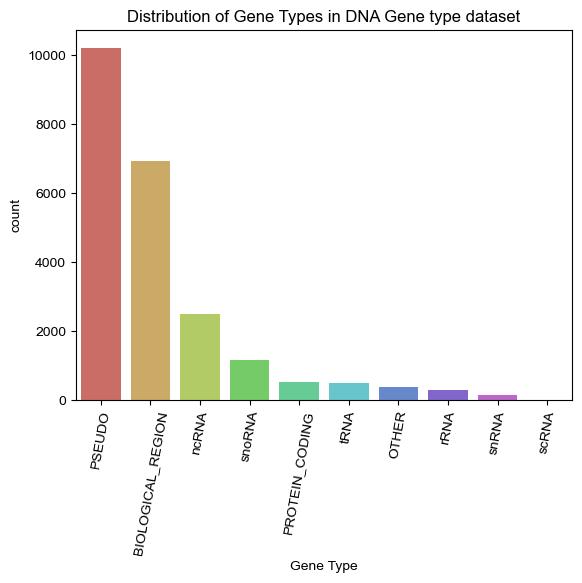

In [15]:
# Visualising Gene Type Distributions
sns.countplot(data=DNA_seq, x='GeneType', order=DNA_seq['GeneType'].value_counts().index, palette='hls')
sns.set_theme(style="whitegrid")
plt.title('Distribution of Gene Types in DNA Gene type dataset')
plt.xlabel('Gene Type')
plt.xticks(rotation=80)
plt.tight_layout

/var/folders/2y/zt7rjpk57tx65mtxqr_k0_980000gn/T/ipykernel_87121/50460491.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=splice_seq, x='Class', order=splice_seq['Class'].value_counts().index, palette='flare')


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

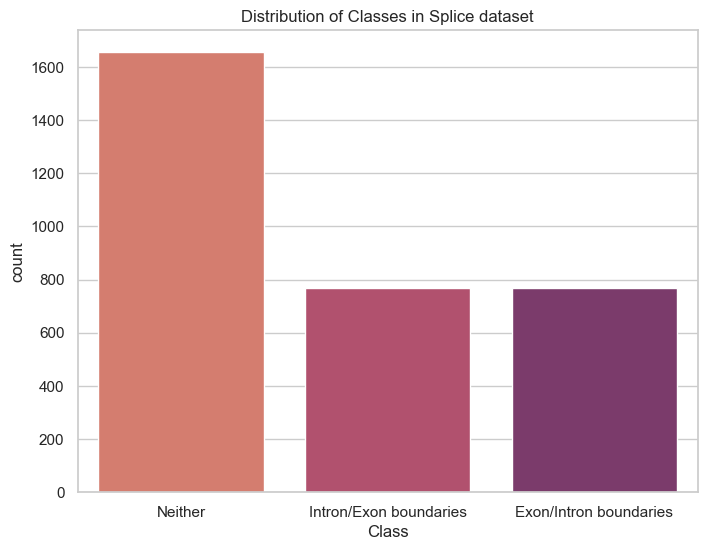

In [16]:
# Visualising Splice Distributions
plt.figure(figsize=(8, 6))
sns.countplot(data=splice_seq, x='Class', order=splice_seq['Class'].value_counts().index, palette='flare')
sns.set_theme(style="whitegrid")
plt.title('Distribution of Classes in Splice dataset')
plt.xticks(ticks=[0, 1, 2], labels=['Neither', 'Intron/Exon boundaries', 'Exon/Intron boundaries'])
plt.xlabel('Class')
plt.tight_layout

In [17]:
X_splice = splice_seq["Sequence"]
Y_splice = splice_seq["Class"]

label_encoder_splice = LabelEncoder()

Y_splice_encoded = label_encoder_splice.fit_transform(
    Y_splice
)

print(label_encoder_splice.classes_)

['EI' 'IE' 'N']


In [18]:
# Splits the splice data into 70% training (X_train_splice) and 30% temporary.
X_train_splice, X_temp_splice, Y_train_splice, Y_temp_splice = train_test_split(X_splice, Y_splice_encoded, test_size=0.30, random_state=22, stratify=Y_splice_encoded)

# Splits the temporary splice data from the 30% in half resulting in 15% of data being available for validation and 15% for testing.
X_val_splice, X_test_splice, Y_val_splice, Y_test_splice = train_test_split(X_temp_splice, Y_temp_splice, test_size=0.50, random_state=22, stratify=Y_temp_splice)

### Creating a CNN

In [19]:
# Improving performance on my mac system
device = torch.device("mps" if torch.backends.mps.is_available() else 'cpu')

#(PyTorch, 2026)


In [20]:
def one_hot_encode(sequence):
    mapping = {"A":0,'C':1,'G':2,'T':3}
    encoded = torch.zeros(4, len(sequence), dtype=torch.float32)

    for location, base in enumerate(sequence):
        if base in mapping:
            encoded[mapping[base], location] = 1
    return encoded

one_hot_encode('ACGTACGT')

tensor([[1., 0., 0., 0., 1., 0., 0., 0.],
        [0., 1., 0., 0., 0., 1., 0., 0.],
        [0., 0., 1., 0., 0., 0., 1., 0.],
        [0., 0., 0., 1., 0., 0., 0., 1.]])

In [21]:

class DNA_dataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = pd.Series(sequences).reset_index(drop = True)
        self.labels = pd.Series(labels).reset_index(drop = True)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, index): 
        sequence = one_hot_encode(self.sequences.iloc[index])
        label = torch.tensor(self.labels.iloc[index], dtype=torch.long)
        return sequence, label

# (jiazhuang, 2019)

In [22]:
# Initialising Pytorch Dataset for non-splicing dataset

train_dataset_DNA = DNA_dataset(X_train_DNA, Y_train_DNA)
val_dataset_DNA = DNA_dataset(X_val_DNA, Y_val_DNA)
test_dataset_DNA = DNA_dataset(X_test_DNA, Y_test_DNA)

# Initialising Pytorch Dataset for splicing dataset
train_dataset_splice = DNA_dataset(X_train_splice, Y_train_splice)
val_dataset_splice = DNA_dataset(X_val_splice, Y_val_splice)
test_dataset_splice = DNA_dataset(X_test_splice, Y_test_splice)

In [23]:
# The dataloaders

generator = torch.Generator()
generator.manual_seed(22)

# DNA
train_loader_DNA = DataLoader(train_dataset_DNA, batch_size=1, shuffle=True, generator=generator)
val_loader_DNA = DataLoader(val_dataset_DNA,batch_size=1, shuffle=False, generator=generator)
test_loader_DNA = DataLoader(test_dataset_DNA, batch_size=1,shuffle=False, generator=generator)

# Splice
train_loader_splice = DataLoader(train_dataset_splice, batch_size=1, shuffle=True, generator=generator)
val_loader_splice = DataLoader(val_dataset_splice,batch_size=1, shuffle=False, generator=generator)
test_loader_splice = DataLoader(test_dataset_splice, batch_size=1, shuffle=False, generator=generator)

# (PyTorch, 2024)

CNN class

In [24]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels = 4, out_channels = 32,
                               padding = 0, kernel_size = 3)
        self.conv2 = nn.Conv1d(in_channels = 32, out_channels = 64,
                                       padding = 0, kernel_size = 2)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(64, num_classes)
    def forward(self, value):
        value = F.relu(self.conv1(value))
        value = F.relu(self.conv2(value))

        # Global pooling??
        value = torch.max(value, dim = 2).values

        value = self.dropout(value)
        value = self.fc(value)
        return value

In [25]:
# Creating the models themselves 

# DNA
num_classes_DNA = len(label_encoder_DNA.classes_)
model_DNA = CNN(num_classes=num_classes_DNA).to(device)

# Splice
num_classes_splice = len(label_encoder_splice.classes_)
model_splice = CNN(num_classes=num_classes_splice).to(device)

Loss function and optimiser

The optimiser chosen was Adam (Adaptive Moment Estimation) due to its advantages as a combination of Momentum and RMSProp optimiser algorithms, Adam is the most famous optimisation algorithm in deep learning and hence was chosen (Vyacheslav Efimov, 2023) 

In [26]:
# Starting loss function
loss_fn = nn.CrossEntropyLoss()

# Train loop
def train_loop(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset)
    # model set to training mode
    model.train()
    total_loss = 0.0

    for X, y in dataloader:
        # Move DNA sequence and Label to device
        X = X.to(device)
        y = y.to(device)

        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        

        total_loss += loss.item()
    # average training loss
    return (total_loss / len(dataloader))

# Test loop
def evaluate_loop(dataloader, model, loss_fn, device):
    # Set the model to evaluation mode
    model.eval()
    total_loss = 0.0
    y_true = []
    y_pred = []
    y_prob = []

    # The code below ensures that no gradients are computed during test mode
    with torch.no_grad():
        for X, y in dataloader:
            X = X.to(device)
            y = y.to(device)

            pred = model(X)
            total_loss += loss_fn(pred, y).item()

            probabilities = F.softmax(pred, dim=1)
            # Predicted class
            predicted_class = pred.argmax(dim = 1)
            y_true.extend(y.cpu().numpy())
            y_pred.extend(predicted_class.cpu().numpy())
            y_prob.extend(probabilities.cpu().numpy())

    average_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(y_true, y_pred)
    recall =  recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro')
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)

    auroc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')

    return average_loss, accuracy, precision, recall, f1, auroc

# (PyTorch, 2024)



Note for macro f1: 
computed using the unweighted mean of all the per-class F1 scores (Leung, 2022). Which is chosen since we want all classes to be treated equally

# Dataset training

Tuning for best learning rate:

In [27]:
initial_model_state = copy.deepcopy(model_DNA.state_dict())

learning_rate = [0.0001, 0.001, 0.01]
best_f1_score = -1
best_learning_rate = 0

for lr in learning_rate:
    print(f"Testing learning rate: {lr}")

    # resettign CNN
    model_DNA.load_state_dict(initial_model_state)
    optimizer_DNA = torch.optim.Adam(model_DNA.parameters(), lr = lr)
    best_model_for_lr = -1

    for epoch in range(3):
        train_loss = train_loop(train_loader_DNA, model_DNA, loss_fn, optimizer_DNA, device)

        # Validate
        val_loss, val_accuracy, val_precision, val_recall, val_f1, val_auroc = evaluate_loop(val_loader_DNA, model_DNA, loss_fn, device)
        print(f"\nEpoch {epoch}")
        print(f"Training Loss: {train_loss}\nValidation_loss: {val_loss}\
                \nAccuracy: {val_accuracy}\nPrecision: {val_precision}\nRecall: {val_recall}\nMacro F1: {val_f1}\nAUROC: {val_auroc}")

        # Save the model if it has the best F1 score so far
        if val_f1 > best_model_for_lr: 
            best_model_for_lr = val_f1
    print(f"Best F1 score for learning rate {lr}: {best_model_for_lr}\n")
    if best_model_for_lr > best_f1_score:
        best_f1_score = best_model_for_lr
        best_learning_rate = lr

Testing learning rate: 0.0001

Epoch 0
Training Loss: 1.4092341797562646
Validation_loss: 1.3285940289849232                
Accuracy: 0.4831759149940968
Precision: 0.14719137217461867
Recall: 0.12398893992611534
Macro F1: 0.09634735413888254
AUROC: 0.7158062861795863

Epoch 1
Training Loss: 1.2879538313181091
Validation_loss: 1.2249199931093062                
Accuracy: 0.54456906729634
Precision: 0.17184959187974214
Recall: 0.16557091991083783
Macro F1: 0.15819210999696054
AUROC: 0.7379358426301716

Epoch 2
Training Loss: 1.217220330418257
Validation_loss: 1.1560142337220338                
Accuracy: 0.5867768595041323
Precision: 0.38625188055690673
Recall: 0.3019167312808779
Macro F1: 0.313141140730766
AUROC: 0.7594737794340616
Best F1 score for learning rate 0.0001: 0.313141140730766

Testing learning rate: 0.001

Epoch 0
Training Loss: 1.252136578994385
Validation_loss: 1.1561765518949896                
Accuracy: 0.5050177095631642
Precision: 0.4400030859264558
Recall: 0.37652258

Further tuning with the best learning rate

In [28]:
model_DNA.load_state_dict(initial_model_state)

best_f1_score = -1
best_epoch = 0
best_model_state = None

print(f'selected learning rate being used: {best_learning_rate}')

# Initializing Optimizer
optimizer_DNA = torch.optim.Adam(model_DNA.parameters(), lr = best_learning_rate) 

for epoch in range(10):
    train_loss = train_loop(train_loader_DNA, model_DNA, loss_fn, optimizer_DNA, device)

    # Validate
    val_loss, val_accuracy, val_precision, val_recall, val_f1, val_auroc = evaluate_loop(
        val_loader_DNA, model_DNA, loss_fn, device
    )
    print(f"\nEpoch {epoch}")
    print(f"Training Loss: {train_loss}\nValidation_loss: {val_loss}\
        \nAccuracy: {val_accuracy}\nPrecision: {val_precision}\nRecall: {val_recall}\nMacro F1: {val_f1}\nAUROC: {val_auroc}")

    # Save the model if it has the best F1 score so far
    if val_f1 > best_f1_score: 
        best_f1_score = val_f1
        best_epoch = epoch
        best_model_state = copy.deepcopy(model_DNA.state_dict())
print(f"Best F1 score: {best_f1_score} at epoch {best_epoch}\n")
model_DNA.load_state_dict(best_model_state)

selected learning rate being used: 0.001

Epoch 0
Training Loss: 1.2614225362590166
Validation_loss: 1.1347053234928333        
Accuracy: 0.5923848878394333
Precision: 0.43790508315674637
Recall: 0.3751776239040097
Macro F1: 0.38562198080300175
AUROC: 0.7985457808698755

Epoch 1
Training Loss: 1.171794310988483
Validation_loss: 1.1290496765265359        
Accuracy: 0.5799881936245572
Precision: 0.437327643997157
Recall: 0.3821137149871614
Macro F1: 0.38504835549432215
AUROC: 0.8040874610823845

Epoch 2
Training Loss: 1.157499266366438
Validation_loss: 1.1455485979040123        
Accuracy: 0.570543093270366
Precision: 0.4711842356879996
Recall: 0.36015729426496385
Macro F1: 0.3796478473427034
AUROC: 0.8153687578857545

Epoch 3
Training Loss: 1.1434115684974047
Validation_loss: 1.1032635171137917        
Accuracy: 0.5847107438016529
Precision: 0.4503278103569462
Recall: 0.3944686559916809
Macro F1: 0.3993596913574554
AUROC: 0.8265415666517053

Epoch 4
Training Loss: 1.135026491918249
Valid

<All keys matched successfully>

In [29]:
print("Learning rate:", best_learning_rate)

Learning rate: 0.001


Tuning for best learning rate:

In [30]:
initial_model_state = copy.deepcopy(model_splice.state_dict())

learning_rate = [0.0001, 0.001, 0.01]
best_f1_score = -1
best_learning_rate = 0

for lr in learning_rate:
    print(f"Testing learning rate: {lr}")

    # resettign CNN
    model_splice.load_state_dict(initial_model_state)
    optimizer_splice = torch.optim.Adam(model_splice.parameters(), lr = lr)
    best_model_for_lr = -1

    for epoch in range(3):
        train_loss = train_loop(train_loader_splice, model_splice, loss_fn, optimizer_splice, device)

        # Validate
        val_loss, val_accuracy, val_precision, val_recall, val_f1, val_auroc = evaluate_loop(val_loader_splice, model_splice, loss_fn, device)
        print(f"\nEpoch {epoch}")
        print(f"Training Loss: {train_loss}\nValidation_loss: {val_loss}\
                \nAccuracy: {val_accuracy}\nPrecision: {val_precision}\nRecall: {val_recall}\nMacro F1: {val_f1}\nAUROC: {val_auroc}")

        # Save the model if it has the best F1 score so far
        if val_f1 > best_model_for_lr: 
            best_model_for_lr = val_f1
    print(f"\nBest F1 score for learning rate {lr}: {best_model_for_lr}\n")
    if best_model_for_lr > best_f1_score:
        best_f1_score = best_model_for_lr
        best_learning_rate = lr

Testing learning rate: 0.0001

Epoch 0
Training Loss: 1.027778484124108
Validation_loss: 1.0189534981879231                
Accuracy: 0.5188284518828452
Precision: 0.17294281729428174
Recall: 0.3333333333333333
Macro F1: 0.22773186409550047
AUROC: 0.6435636970237888

Epoch 1
Training Loss: 1.0168919805128693
Validation_loss: 1.0117194701188779                
Accuracy: 0.5188284518828452
Precision: 0.17294281729428174
Recall: 0.3333333333333333
Macro F1: 0.22773186409550047
AUROC: 0.670417614884018

Epoch 2
Training Loss: 1.01238873440804
Validation_loss: 1.003967399502399                
Accuracy: 0.5188284518828452
Precision: 0.17294281729428174
Recall: 0.3333333333333333
Macro F1: 0.22773186409550047
AUROC: 0.6865233522268458

Best F1 score for learning rate 0.0001: 0.22773186409550047

Testing learning rate: 0.001

Epoch 0
Training Loss: 1.0206275014828206
Validation_loss: 0.9846355614552438                
Accuracy: 0.5188284518828452
Precision: 0.17294281729428174
Recall: 0.33333

Further tuning with the best learning rate

In [31]:
model_splice.load_state_dict(initial_model_state)

best_f1_score = -1
best_epoch = 0
best_model_state = None

print(f'selected learning rate being used: {best_learning_rate}')


# Initializing Optimizer
optimizer_splice = torch.optim.Adam(model_splice.parameters(), lr = best_learning_rate) 

for epoch in range(10):
    train_loss = train_loop(train_loader_splice, model_splice, loss_fn, optimizer_splice, device)

    # Validate
    val_loss, val_accuracy, val_precision, val_recall, val_f1, val_auroc = evaluate_loop(
        val_loader_splice, model_splice, loss_fn, device
    )
    print(f"\nEpoch {epoch}")
    print(f"Training Loss: {train_loss}\nValidation_loss: {val_loss}\
        \nAccuracy: {val_accuracy}\nPrecision: {val_precision}\nRecall: {val_recall}\nMacro F1: {val_f1}\nAUROC: {val_auroc}")

    # Save the model if it has the best F1 score so far
    if val_f1 > best_f1_score: 
        best_f1_score = val_f1
        best_epoch = epoch
        best_model_state = copy.deepcopy(model_splice.state_dict())

print(f"\nBest F1 score: {best_f1_score} at epoch {best_epoch}\n")
model_splice.load_state_dict(best_model_state)

selected learning rate being used: 0.001

Epoch 0
Training Loss: 1.0080176949954813
Validation_loss: 0.9657398113146985        
Accuracy: 0.5711297071129707
Precision: 0.60597618153234
Recall: 0.4524310425432445
Macro F1: 0.45830031883452227
AUROC: 0.7073659906472606

Epoch 1
Training Loss: 0.9243308396795593
Validation_loss: 0.8779604610164794        
Accuracy: 0.5962343096234309
Precision: 0.6278515912521677
Recall: 0.504312762973352
Macro F1: 0.4921288515406162
AUROC: 0.7717759322151774

Epoch 2
Training Loss: 0.8777517442158984
Validation_loss: 0.8121576565765936        
Accuracy: 0.6443514644351465
Precision: 0.6504563327922247
Recall: 0.5803062178588125
Macro F1: 0.5969139864438046
AUROC: 0.8018845377142586

Epoch 3
Training Loss: 0.8501991693687864
Validation_loss: 0.8315166070994972        
Accuracy: 0.608786610878661
Precision: 0.7048991961190728
Recall: 0.47973352033660593
Macro F1: 0.4803935889284139
AUROC: 0.796912015089052

Epoch 4
Training Loss: 0.8447873886446087
Validat

<All keys matched successfully>

DNA 3-mer TF-IDF Logistic Regression

In [32]:
# Creating a TF-IDF representation based on character 3-mers
DNA_tfidf = TfidfVectorizer(analyzer='char', ngram_range=(3, 3), lowercase=False) 

X_train_DNA_tf = DNA_tfidf.fit_transform(X_train_DNA.astype(str))
X_val_DNA_tf = DNA_tfidf.transform(X_val_DNA.astype(str))
X_test_DNA_tf = DNA_tfidf.transform(X_test_DNA.astype(str))

# Logistic Regression
DNA_lr = LogisticRegression(max_iter = 1000, random_state = 22)
DNA_lr.fit(X_train_DNA_tf, Y_train_DNA)
Y_val_pred_DNA = DNA_lr.predict(X_val_DNA_tf)


Splice 3-mer TF-IDF Logistic Regression

In [33]:
# Creating a TF-IDF representation based on character 3-mers
splice_tfidf = TfidfVectorizer(analyzer='char', ngram_range=(3, 3), lowercase=False) 

X_train_splice_tf = splice_tfidf.fit_transform(X_train_splice.astype(str))
X_val_splice_tf = splice_tfidf.transform(X_val_splice.astype(str))
X_test_splice_tf = splice_tfidf.transform(X_test_splice.astype(str))

# Logistic Regression
splice_lr = LogisticRegression(max_iter = 1000, random_state = 22)
splice_lr.fit(X_train_splice_tf, Y_train_splice)
Y_val_pred_splice = splice_lr.predict(X_val_splice_tf)


In [34]:
# Under log regression line
DNA_grid = GridSearchCV(DNA_lr, param_grid = {'C':[0.01, 0.1, 1, 10, 100], 'class_weight':[None, 'balanced']}, cv=5, scoring='f1_macro')
DNA_grid.fit(X_train_DNA_tf, Y_train_DNA)
print(f'Best parameters: {DNA_grid.best_params_}')
print(f'Best cross-validation macro F1 score: {DNA_grid.best_score_}')

best_DNA_lr = DNA_grid.best_estimator_

# (scikit-learn developers, 2023, scikit-learn developers, 2012)

Best parameters: {'C': 100, 'class_weight': None}
Best cross-validation macro F1 score: 0.5649475894691435


In [35]:
# Testing the model on the test set
Y_test_pred_DNA = best_DNA_lr.predict(X_test_DNA_tf)
Y_test_prob_DNA = best_DNA_lr.predict_proba(X_test_DNA_tf)

print(f'Accuracy: {accuracy_score(Y_test_DNA, Y_test_pred_DNA)}')
print(f'Precision: {precision_score(Y_test_DNA, Y_test_pred_DNA, average="macro", zero_division=0)}')
print(f'Recall: {recall_score(Y_test_DNA, Y_test_pred_DNA, average="macro", zero_division=0)}')
print(f'Macro F1: {f1_score(Y_test_DNA, Y_test_pred_DNA, average="macro", zero_division=0)}')
print(f'AUROC: {roc_auc_score(Y_test_DNA, Y_test_prob_DNA, multi_class="ovr", average="macro")}')

Accuracy: 0.6701091767483033
Precision: 0.6331225390395839
Recall: 0.5090207631646635
Macro F1: 0.5450799792325545
AUROC: 0.9010960269754098


In [36]:
# Under log regression line

splice_grid = GridSearchCV(splice_lr, param_grid = {'C':[0.01, 0.1, 1, 10, 100]}, cv=5, scoring='f1_macro')
splice_grid.fit(X_train_splice_tf, Y_train_splice)
print(f'Best parameters: {splice_grid.best_params_}')
print(f'Best cross-validation macro F1 score: {splice_grid.best_score_}')

best_splice_lr = splice_grid.best_estimator_

Best parameters: {'C': 100}
Best cross-validation macro F1 score: 0.6010344081128078


In [37]:
# Testing the model on the test set
Y_test_pred_splice = best_splice_lr.predict(X_test_splice_tf)
Y_test_prob_splice = best_splice_lr.predict_proba(X_test_splice_tf)

print(f'Accuracy: {accuracy_score(Y_test_splice, Y_test_pred_splice)}')
print(f'Precision: {precision_score(Y_test_splice, Y_test_pred_splice, average="macro", zero_division=0)}')
print(f'Recall: {recall_score(Y_test_splice, Y_test_pred_splice, average="macro", zero_division=0)}')
print(f'Macro F1: {f1_score(Y_test_splice, Y_test_pred_splice, average="macro", zero_division=0)}')
print(f'AUROC: {roc_auc_score(Y_test_splice, Y_test_prob_splice, multi_class="ovr", average="macro")}')

Accuracy: 0.6116910229645094
Precision: 0.5899258375496196
Recall: 0.5669402246667831
Macro F1: 0.5750358874790459
AUROC: 0.7756581989688328


### Visualisations

In [38]:
text = """Dataset: genetype_CNN Training Loss: 1.0994404920713854
Validation_loss: 1.0410888479756457        
Accuracy: 0.6325265643447462
Precision: 0.47242974826489154
Recall: 0.4396573559796386
Macro F1: 0.44840775023952717
AUROC: 0.8477638311224226

Dataset: splice_CNN
Training Loss: 0.8188998006097389
Validation_loss: 0.754557725992911        
Accuracy: 0.6757322175732218
Precision: 0.6943041020089017
Recall: 0.6035764375876578
Macro F1: 0.6271808896286744
AUROC: 0.8267694315332337

Dataset: genetype_LR
Accuracy: 0.6810268515786367
Precision: 0.6599202105285572
Recall: 0.5360776670117374
Macro F1: 0.5680402024253408
AUROC: 0.9074645051865468

Dataset: splice_LR
Accuracy: 0.6116910229645094
Precision: 0.5899258375496196
Recall: 0.5669402246667831
Macro F1: 0.5750358874790459
AUROC: 0.7756581989688328"""

pattern = r"""
Dataset:\s+(?P<Dataset>\w+)\s+
(?:Training\s+Loss:\s+(?P<Training_Loss>[\d.]+)\s+)?
(?:Validation_loss:\s+(?P<Validation_Loss>[\d.]+)\s+)?
Accuracy:\s+(?P<Accuracy>[\d.]+)\s+
Precision:\s+(?P<Precision>[\d.]+)\s+
Recall:\s+(?P<Recall>[\d.]+)\s+
Macro\s+F1:\s+(?P<Macro_F1>[\d.]+)\s+
AUROC:\s+(?P<AUROC>[\d.]+)
"""

metrics = pd.DataFrame(pd.Series(text).str.extractall(pattern, flags=re.X).reset_index(drop=True))
numeric = metrics.drop(columns=['Dataset'])
metrics[numeric.columns] = metrics[numeric.columns].astype(float)
metrics

,Dataset,Training_Loss,Validation_Loss,Accuracy,Precision,Recall,Macro_F1,AUROC
0,genetype_CNN,1.09944,1.041089,0.632527,0.472430,0.439657,0.448408,0.847764
1,splice_CNN,0.81890,0.754558,0.675732,0.694304,0.603576,0.627181,0.826769
2,genetype_LR,NaN,NaN,0.681027,0.659920,0.536078,0.568040,0.907465
3,splice_LR,NaN,NaN,0.611691,0.589926,0.566940,0.575036,0.775658


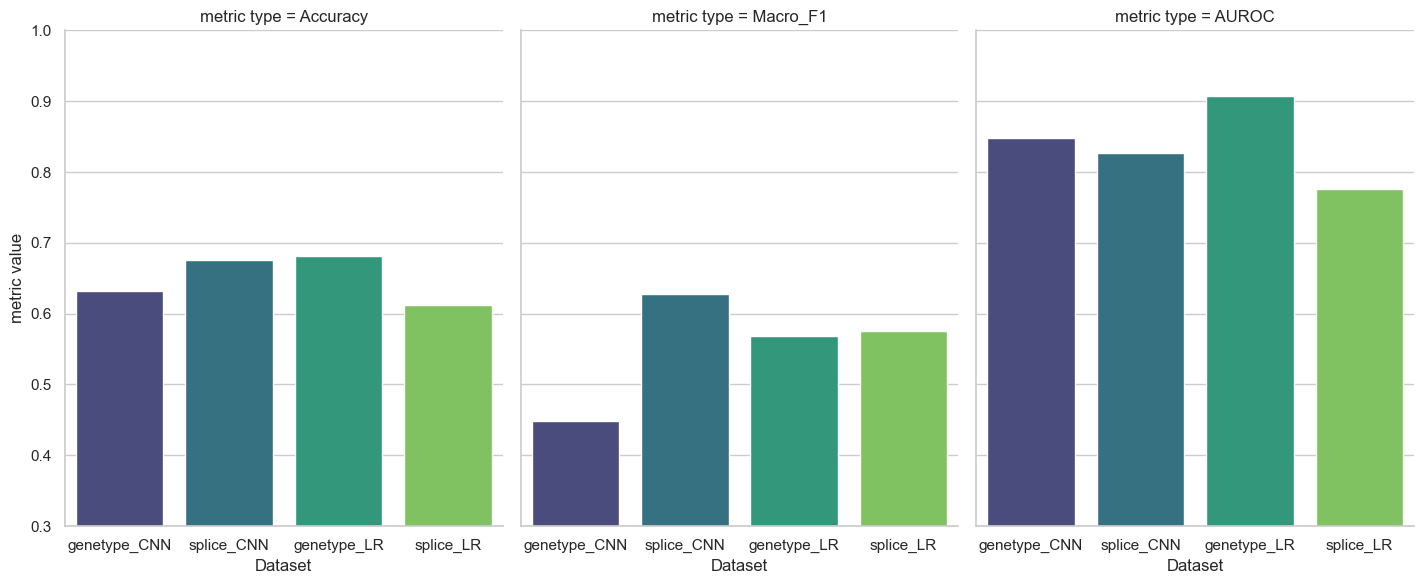

In [39]:
# Combining out chosen metric columns
metrics_all = metrics.melt(
    id_vars=['Dataset'],
    value_vars=['Accuracy', 'Macro_F1', 'AUROC'],
    value_name = 'metric value',
    var_name = 'metric type'
)

# Generating facet grid and then map combined barplots to grid
grid = sns.FacetGrid(metrics_all, height = 6, aspect = 0.8, col = 'metric type')
grid.map_dataframe(sns.barplot, x='Dataset', y = 'metric value', hue = 'Dataset', palette = 'viridis')
grid.set(ylim = (0.3, 1))

In [40]:
text = """Epoch 0
Training Loss: 1.2544886087351481
Validation_loss: 1.1288882872835242        
Accuracy: 0.5870720188902007
Precision: 0.42194305983488617
Recall: 0.3688299122044872
Macro F1: 0.3842378726283004
AUROC: 0.7753775220569405

Epoch 1
Training Loss: 1.161842075138078
Validation_loss: 1.110469659717826        
Accuracy: 0.5838252656434475
Precision: 0.42757575680422294
Recall: 0.37457690329389226
Macro F1: 0.3792746879238884
AUROC: 0.8130323239321179

Epoch 2
Training Loss: 1.1410069733684718
Validation_loss: 1.1278767381149313        
Accuracy: 0.5652302243211335
Precision: 0.4181216900724732
Recall: 0.38055991860097405
Macro F1: 0.3615585794084302
AUROC: 0.8204785452653413

Epoch 3
Training Loss: 1.1308661534727524
Validation_loss: 1.0962903029477793        
Accuracy: 0.601534828807556
Precision: 0.44333116777566073
Recall: 0.42270133032339047
Macro F1: 0.417723486563354
AUROC: 0.824890923019836

Epoch 4
Training Loss: 1.1281155793020345
Validation_loss: 1.0991315585368675        
Accuracy: 0.6254427390791027
Precision: 0.4501427707527557
Recall: 0.4292054533950267
Macro F1: 0.43608013920651945
AUROC: 0.8409755146494867

Epoch 5
Training Loss: 1.1158629085776188
Validation_loss: 1.0797787728304882        
Accuracy: 0.6038961038961039
Precision: 0.4563839114350252
Recall: 0.4253564288922072
Macro F1: 0.42708711606679456
AUROC: 0.8374374858896229

Epoch 6
Training Loss: 1.1119919137948588
Validation_loss: 1.077436908104247        
Accuracy: 0.6092089728453365
Precision: 0.47009030529780266
Recall: 0.4145319751846965
Macro F1: 0.42781578173029167
AUROC: 0.8424465618582629

Epoch 7
Training Loss: 1.1075817472450282
Validation_loss: 1.0596095060461246        
Accuracy: 0.6236717827626919
Precision: 0.4831364524369907
Recall: 0.42380179036799587
Macro F1: 0.4386071680822693
AUROC: 0.841033419690133

Epoch 8
Training Loss: 1.0997932950371445
Validation_loss: 1.058587920507845        
Accuracy: 0.6201298701298701
Precision: 0.4746654350673315
Recall: 0.43322520348994026
Macro F1: 0.440070044509835
AUROC: 0.8414283606731069

Epoch 9
Training Loss: 1.0994404920713854
Validation_loss: 1.0410888479756457        
Accuracy: 0.6325265643447462
Precision: 0.47242974826489154
Recall: 0.4396573559796386
Macro F1: 0.44840775023952717
AUROC: 0.8477638311224226
"""

pattern = r"""
Epoch\s+(?P<Epoch>\d+)\s+
(?:Training\s+Loss:\s+(?P<Training_Loss>[\d.]+)\s+)?
(?:Validation_loss:\s+(?P<Validation_Loss>[\d.]+)\s+)?
Accuracy:\s+(?P<Accuracy>[\d.]+)\s+
Precision:\s+(?P<Precision>[\d.]+)\s+
Recall:\s+(?P<Recall>[\d.]+)\s+
Macro\s+F1:\s+(?P<Macro_F1>[\d.]+)\s+
AUROC:\s+(?P<AUROC>[\d.]+)
"""

f1_change = pd.DataFrame(pd.Series(text).str.extractall(pattern, flags=re.X).reset_index(drop=True))
f1_change= f1_change.astype(float)
f1_change



,Epoch,Training_Loss,Validation_Loss,Accuracy,Precision,Recall,Macro_F1,AUROC
0,0.0,1.254489,1.128888,0.587072,0.421943,0.368830,0.384238,0.775378
1,1.0,1.161842,1.110470,0.583825,0.427576,0.374577,0.379275,0.813032
2,2.0,1.141007,1.127877,0.565230,0.418122,0.380560,0.361559,0.820479
3,3.0,1.130866,1.096290,0.601535,0.443331,0.422701,0.417723,0.824891
4,4.0,1.128116,1.099132,0.625443,0.450143,0.429205,0.436080,0.840976
5,5.0,1.115863,1.079779,0.603896,0.456384,0.425356,0.427087,0.837437
6,6.0,1.111992,1.077437,0.609209,0.470090,0.414532,0.427816,0.842447
7,7.0,1.107582,1.059610,0.623672,0.483136,0.423802,0.438607,0.841033
8,8.0,1.099793,1.058588,0.620130,0.474665,0.433225,0.440070,0.841428
9,9.0,1.099440,1.041089,0.632527,0.472430,0.439657,0.448408,0.847764


/var/folders/2y/zt7rjpk57tx65mtxqr_k0_980000gn/T/ipykernel_87121/724304445.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


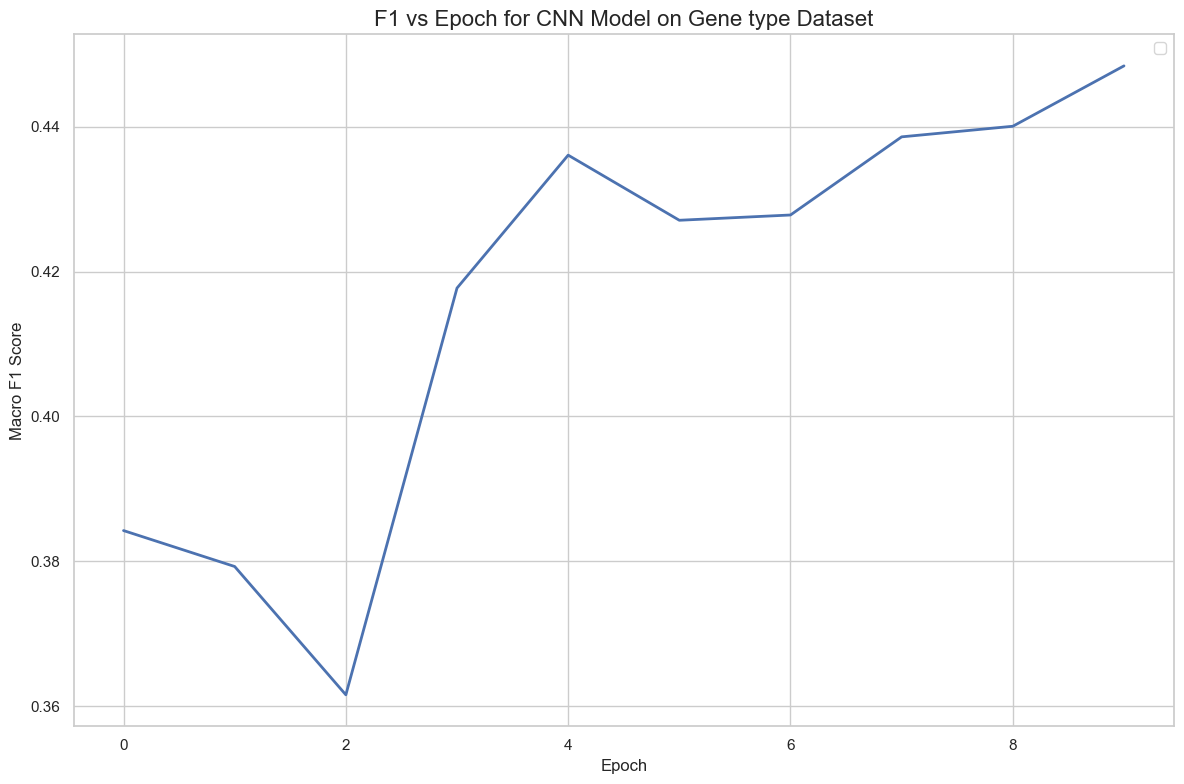

In [41]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(12, 8))
sns.lineplot(data=f1_change, x="Epoch", y="Macro_F1", estimator="mean", errorbar="sd",
    linewidth=2, ax=ax)

ax.set_title("F1 vs Epoch for CNN Model on Gene type Dataset", fontsize=16)
ax.set_xlabel("Epoch")
ax.set_ylabel("Macro F1 Score")
plt.tight_layout()
plt.legend()
plt.show()

### Functions for recreating method with other data sets

In [42]:
def validate_LR_model(X_train, X_test, Y_train, Y_test, random_state, blank_one, blank_two, blank_three):
    # Creating a TF-IDF representation based on character 3-mers
    tfidf = TfidfVectorizer(analyzer='char', ngram_range=(3, 3), lowercase=False) 

    X_train_tf = tfidf.fit_transform(X_train.astype(str))
    X_test_tf = tfidf.transform(X_test.astype(str))

    # Logistic Regression
    model_lr = LogisticRegression(max_iter = 1000, random_state = random_state)
    model_grid = GridSearchCV(model_lr, param_grid = {'C':[0.01, 0.1, 1, 10, 100], 'class_weight':[None, 'balanced']}, cv=5, scoring='f1_macro')
    model_grid.fit(X_train_tf, Y_train)
    best_lr = model_grid.best_estimator_

    # Testing the model on the test set
    Y_test_pred = best_lr.predict(X_test_tf)
    Y_test_prob = best_lr.predict_proba(X_test_tf)

    # AUROC score calculation, handling binary and multi-class cases separately
    if len(best_lr.classes_) == 2: # Binary
        auroc = roc_auc_score(Y_test, Y_test_prob[:, 1], multi_class="ovr", average="macro")
    else: # Multi-class
        auroc = roc_auc_score(Y_test, Y_test_prob, multi_class="ovr", average="macro")

    return {
        'Accuracy': accuracy_score(Y_test, Y_test_pred),
        'Precision': precision_score(Y_test, Y_test_pred, average="macro", zero_division=0),
        'Recall': recall_score(Y_test, Y_test_pred, average="macro", zero_division=0),
        'Macro F1': f1_score(Y_test, Y_test_pred, average="macro", zero_division=0),
        'AUROC': auroc,
        'Features': f'best parameters:{model_grid.best_params_}'}

    


In [43]:
def validate_CNN_model(X_train, X_test, Y_train, Y_test, random_state, validation_size, dataset_class, model):
    # Create validation and test splits for folds
    X_train_2, X_val, Y_train_2, Y_val = train_test_split(X_train, Y_train, test_size=validation_size, random_state=random_state, stratify=Y_train)

    # Creating fold specific datasets
    train_dataset = dataset_class(X_train_2, Y_train_2)
    val_dataset = dataset_class(X_val, Y_val)
    test_dataset = dataset_class(X_test, Y_test)

    # Creating fold specific loaders
    generator = torch.Generator()
    generator.manual_seed(random_state)
    train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, generator=generator)
    val_loader = DataLoader(val_dataset,batch_size=1, shuffle=False, generator=generator)
    test_loader = DataLoader(test_dataset, batch_size=1,shuffle=False, generator=generator)

    # Initial model prior to testing
    initial_model_state = copy.deepcopy(model.state_dict())

    learning_rate = [0.0001, 0.001, 0.01]
    best_f1_score = -1
    best_learning_rate = 0

    # Save learning rate after epoch testing
    best_lr_state = None
    best_lr_optimiser_state = None

    # Final save
    best_epoch = 0
    best_model = None

    for lr in learning_rate:
        # resettign CNN
        model.load_state_dict(initial_model_state)
        optimizer = torch.optim.Adam(model.parameters(), lr = lr)
        best_model_for_lr = -1
        best_lr_state = None
        best_lr_epoch = None

        for epoch in range(3):
            train_loss = train_loop(train_loader, model, loss_fn, optimizer, device)
            # Validate
            val_loss, val_accuracy, val_precision, val_recall, val_f1, val_auroc = evaluate_loop(val_loader, model, loss_fn, device)
            # Save the model if it has the best F1 score so far
            if val_f1 > best_model_for_lr: 
                best_model_for_lr = val_f1
                best_lr_state = copy.deepcopy(model.state_dict())
                best_lr_epoch = epoch
        if best_model_for_lr > best_f1_score:
            best_f1_score = best_model_for_lr
            best_learning_rate = lr 

            # Save
            best_lr_state = copy.deepcopy(model.state_dict())
            best_lr_optimiser_state = copy.deepcopy(optimizer.state_dict())
            best_model = best_lr_state
            best_epoch = best_lr_epoch


    # Adjusting so that now my code instead retains the best model states (so it doesnt have to repeat)
    model.load_state_dict(best_lr_state) # Change from past code
    optimizer = torch.optim.Adam(model.parameters(), lr = best_learning_rate)
    optimizer.load_state_dict(best_lr_optimiser_state) # Change from past code

    for epoch in range(3, 10):
        train_loss = train_loop(train_loader, model, loss_fn, optimizer, device)

        # Validate
        val_loss, val_accuracy, val_precision, val_recall, val_f1, val_auroc = evaluate_loop(
            val_loader, model, loss_fn, device
         )

        # Save the model if it has the best F1 score so far
        if val_f1 > best_f1_score: 
            best_f1_score = val_f1
            best_epoch = epoch
            best_model_state = copy.deepcopy(model.state_dict())

    # Test once - this is also a change!! 
    test_loss, test_accuracy, test_precision, test_recall, test_f1, test_auroc = evaluate_loop(test_loader, model, loss_fn, device)

    return {
            'Accuracy': test_accuracy,
            'Precision': test_precision,
            'Recall': test_recall,
            'Macro F1': test_f1,
            'AUROC': test_auroc,
            'Features': f'Learning Rate:{best_learning_rate}'}

# Check if the test one thing is new (should be)

# Deliberation
### 5-fold cross validation (was it unbiased?)

## REWORD


In [44]:

from sklearn.model_selection import KFold


seed = 22 
kfold = KFold(n_splits=5, shuffle=True, random_state=seed)
cross_validation = pd.DataFrame(columns=['Model', 'Dataset', 'Fold', 'Accuracy', 'Precision', 'Recall', 'Macro F1', 'AUROC', 'Features'])

def validation(X, Y, Dataset_name, seed, model, model_name, validation_size = None, dataset_class= None, CNN_model = None):
    X = X.reset_index(drop=True)
    Y = Y.reset_index(drop=True)
    for fold, (train_index, test_index) in enumerate(kfold.split(X), start=1):
        X_train = X.iloc[train_index]
        X_test = X.iloc[test_index]
        Y_train = Y.iloc[train_index]
        Y_test =  Y.iloc[test_index]
        results = model(X_train, X_test, Y_train, Y_test, seed, validation_size, dataset_class, CNN_model)
        cross_validation.loc[len(cross_validation)] = [model_name, Dataset_name, fold] + list(results.values())

validation(X_DNA_filtered, pd.Series(Y_DNA_filtered), 'DNA', seed, validate_LR_model, 'Logistic Regression')

cross_validation

,Model,Dataset,Fold,Accuracy,Precision,Recall,Macro F1,AUROC,Features
0,Logistic Regression,DNA,1,0.683488,0.606994,0.504048,0.527490,0.903469,"best parameters:{'C': 100, 'class_weight': None}"
1,Logistic Regression,DNA,2,0.679504,0.660341,0.535911,0.573242,0.906925,"best parameters:{'C': 100, 'class_weight': None}"
2,Logistic Regression,DNA,3,0.684595,0.634711,0.525772,0.554540,0.911567,"best parameters:{'C': 100, 'class_weight': None}"
3,Logistic Regression,DNA,4,0.680097,0.676529,0.547221,0.582801,0.900398,"best parameters:{'C': 100, 'class_weight': None}"
4,Logistic Regression,DNA,5,0.688953,0.664714,0.531415,0.564221,0.907164,"best parameters:{'C': 100, 'class_weight': None}"


In [45]:
validation(X_splice, pd.Series(Y_splice_encoded), 'Splice', seed, validate_LR_model, 'Logistic Regression')
cross_validation

,Model,Dataset,Fold,Accuracy,Precision,Recall,Macro F1,AUROC,Features
0,Logistic Regression,DNA,1,0.683488,0.606994,0.504048,0.527490,0.903469,"best parameters:{'C': 100, 'class_weight': None}"
1,Logistic Regression,DNA,2,0.679504,0.660341,0.535911,0.573242,0.906925,"best parameters:{'C': 100, 'class_weight': None}"
2,Logistic Regression,DNA,3,0.684595,0.634711,0.525772,0.554540,0.911567,"best parameters:{'C': 100, 'class_weight': None}"
3,Logistic Regression,DNA,4,0.680097,0.676529,0.547221,0.582801,0.900398,"best parameters:{'C': 100, 'class_weight': None}"
4,Logistic Regression,DNA,5,0.688953,0.664714,0.531415,0.564221,0.907164,"best parameters:{'C': 100, 'class_weight': None}"
5,Logistic Regression,Splice,1,0.642633,0.639277,0.685148,0.642522,0.827451,"best parameters:{'C': 10, 'class_weight': 'bal..."
6,Logistic Regression,Splice,2,0.620690,0.611358,0.643649,0.617707,0.811722,"best parameters:{'C': 10, 'class_weight': 'bal..."
7,Logistic Regression,Splice,3,0.611285,0.603414,0.636487,0.610457,0.792403,"best parameters:{'C': 100, 'class_weight': 'ba..."
8,Logistic Regression,Splice,4,0.579937,0.576566,0.629953,0.578991,0.785569,"best parameters:{'C': 1, 'class_weight': 'bala..."
9,Logistic Regression,Splice,5,0.601881,0.592558,0.622453,0.597236,0.779721,"best parameters:{'C': 100, 'class_weight': 'ba..."


In [46]:
validation(X_DNA_filtered, pd.Series(Y_DNA_filtered), 'DNA', seed, validate_CNN_model, 'CNN', 0.2, DNA_dataset, model_DNA)
cross_validation


,Model,Dataset,Fold,Accuracy,Precision,Recall,Macro F1,AUROC,Features
0,Logistic Regression,DNA,1,0.683488,0.606994,0.504048,0.527490,0.903469,"best parameters:{'C': 100, 'class_weight': None}"
1,Logistic Regression,DNA,2,0.679504,0.660341,0.535911,0.573242,0.906925,"best parameters:{'C': 100, 'class_weight': None}"
2,Logistic Regression,DNA,3,0.684595,0.634711,0.525772,0.554540,0.911567,"best parameters:{'C': 100, 'class_weight': None}"
3,Logistic Regression,DNA,4,0.680097,0.676529,0.547221,0.582801,0.900398,"best parameters:{'C': 100, 'class_weight': None}"
4,Logistic Regression,DNA,5,0.688953,0.664714,0.531415,0.564221,0.907164,"best parameters:{'C': 100, 'class_weight': None}"
5,Logistic Regression,Splice,1,0.642633,0.639277,0.685148,0.642522,0.827451,"best parameters:{'C': 10, 'class_weight': 'bal..."
6,Logistic Regression,Splice,2,0.620690,0.611358,0.643649,0.617707,0.811722,"best parameters:{'C': 10, 'class_weight': 'bal..."
7,Logistic Regression,Splice,3,0.611285,0.603414,0.636487,0.610457,0.792403,"best parameters:{'C': 100, 'class_weight': 'ba..."
8,Logistic Regression,Splice,4,0.579937,0.576566,0.629953,0.578991,0.785569,"best parameters:{'C': 1, 'class_weight': 'bala..."
9,Logistic Regression,Splice,5,0.601881,0.592558,0.622453,0.597236,0.779721,"best parameters:{'C': 100, 'class_weight': 'ba..."


In [47]:
validation(X_splice, pd.Series(Y_splice_encoded), 'Splice', seed, validate_CNN_model, 'CNN', 0.2, DNA_dataset, model_splice)
cross_validation


,Model,Dataset,Fold,Accuracy,Precision,Recall,Macro F1,AUROC,Features
0,Logistic Regression,DNA,1,0.683488,0.606994,0.504048,0.527490,0.903469,"best parameters:{'C': 100, 'class_weight': None}"
1,Logistic Regression,DNA,2,0.679504,0.660341,0.535911,0.573242,0.906925,"best parameters:{'C': 100, 'class_weight': None}"
2,Logistic Regression,DNA,3,0.684595,0.634711,0.525772,0.554540,0.911567,"best parameters:{'C': 100, 'class_weight': None}"
3,Logistic Regression,DNA,4,0.680097,0.676529,0.547221,0.582801,0.900398,"best parameters:{'C': 100, 'class_weight': None}"
4,Logistic Regression,DNA,5,0.688953,0.664714,0.531415,0.564221,0.907164,"best parameters:{'C': 100, 'class_weight': None}"
5,Logistic Regression,Splice,1,0.642633,0.639277,0.685148,0.642522,0.827451,"best parameters:{'C': 10, 'class_weight': 'bal..."
6,Logistic Regression,Splice,2,0.620690,0.611358,0.643649,0.617707,0.811722,"best parameters:{'C': 10, 'class_weight': 'bal..."
7,Logistic Regression,Splice,3,0.611285,0.603414,0.636487,0.610457,0.792403,"best parameters:{'C': 100, 'class_weight': 'ba..."
8,Logistic Regression,Splice,4,0.579937,0.576566,0.629953,0.578991,0.785569,"best parameters:{'C': 1, 'class_weight': 'bala..."
9,Logistic Regression,Splice,5,0.601881,0.592558,0.622453,0.597236,0.779721,"best parameters:{'C': 100, 'class_weight': 'ba..."


## References

- Harshvardhan21. (2025, July 8). DNA sequence prediction. Kaggledatasets. https://www.kaggle.com/datasets/harshvardhan21/dna-sequence-prediction/data

- jiazhuang. (2019, January 30). CNN with PyTorch for Beginners. Kaggle. https://www.kaggle.com/code/jiazhuang/cnn-with-pytorch-for-beginners

- Leung, K. (2022, January 4). Micro, macro & weighted averages of F1 score, clearly explained | towards data science. Towards Data Science. https://towardsdatascience.com/micro-macro-weighted-averages-of-f1-score-clearly-explained-b603420b292f/

- PyTorch. (2024). Optimizing model parameters — PyTorch tutorials 2.7.0+CU126 documentation. Pytorch.Org. https://docs.pytorch.org/tutorials/beginner/basics/optimization_tutorial.html

- PyTorch. (2026). MPS backend. Pytorch.Org. https://docs.pytorch.org/docs/2.13/notes/mps.html

- scikit-learn developers. (2023). Model selection: Choosing estimators and their parameters. Scikit-Learn. https://scikit-learn.org/1.3/tutorial/statistical_inference/model_selection.html

- UCI Machine Learning Repository. (1991). UCI machine learning repository. Uci.Edu. https://doi.org/10.24432/C5M888

- Vyacheslav Efimov. (2023, December 30). Understanding deep learning optimizers: Momentum, AdaGrad, RMSProp & adam | towards data science. Towards Data Science. https://towardsdatascience.com/understanding-deep-learning-optimizers-momentum-adagrad-rmsprop-adam-e311e377e9c2/

In [48]:
print("Minimum length:", X_DNA_filtered.str.len().min())

print(X_DNA_filtered.str.len().value_counts().sort_index().head(10))

print("Sequences under 3:")
print(X_DNA_filtered[X_DNA_filtered.str.len() < 3])

print("Sequences under 5:")
print(X_DNA_filtered[X_DNA_filtered.str.len() < 5])

Minimum length: 7
NucleotideSequence
7     1
8     1
9     1
11    1
12    1
13    1
16    4
17    4
18    3
19    2
Name: count, dtype: int64
Sequences under 3:
Series([], Name: NucleotideSequence, dtype: object)
Sequences under 5:
Series([], Name: NucleotideSequence, dtype: object)
